Độ chính xác (Accuracy) của mô hình cơ sở: 77.60%



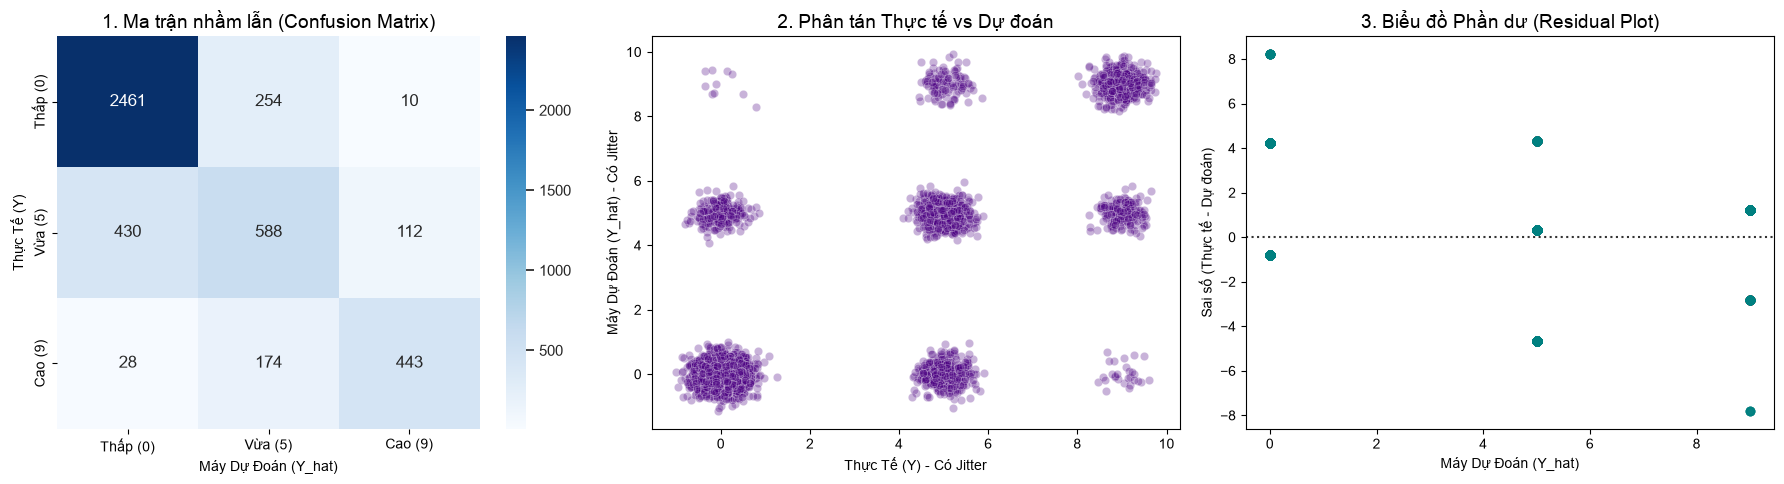

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix

df = pd.read_csv('/Users/hungdan/Documents/Projects/project_01/Diabetes_Risk_Analysis/clean_data_diabetes.csv')
features = ['waist_circumference_cm', 'age', 'fasting_blood_sugar', 'bmi']

X = df[features]
Y = df['diabetes_risk']
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.30, random_state=42)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

pipe.fit(x_train, y_train)
y_hat_test = pipe.predict(x_test)

acc = accuracy_score(y_test, y_hat_test)
print(f"Độ chính xác (Accuracy) của mô hình cơ sở: {acc * 100:.2f}%\n")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.set_theme(style="whitegrid")

#heat_map
cm = confusion_matrix(y_test, y_hat_test, labels=[0, 5, 9])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Thấp (0)', 'Vừa (5)', 'Cao (9)'], 
            yticklabels=['Thấp (0)', 'Vừa (5)', 'Cao (9)'], ax=axes[0])
axes[0].set_title('1. Ma trận nhầm lẫn (Confusion Matrix)', fontsize=14)
axes[0].set_xlabel('Máy Dự Đoán (Y_hat)')
axes[0].set_ylabel('Thực Tế (Y)')

#scatter_plot
y_test_jitter = y_test + np.random.normal(0, 0.3, size=len(y_test))
y_hat_jitter = y_hat_test + np.random.normal(0, 0.3, size=len(y_hat_test))

sns.scatterplot(x=y_test_jitter, y=y_hat_jitter, alpha=0.3, color='indigo', ax=axes[1])
axes[1].set_title('2. Phân tán Thực tế vs Dự đoán', fontsize=14)
axes[1].set_xlabel('Thực Tế (Y) - Có Jitter')
axes[1].set_ylabel('Máy Dự Đoán (Y_hat) - Có Jitter')

#residual_plot
sns.residplot(x=y_hat_test, y=y_test, scatter_kws={'alpha': 0.3, 'color': 'teal'}, ax=axes[2])
axes[2].set_title('3. Biểu đồ Phần dư (Residual Plot)', fontsize=14)
axes[2].set_xlabel('Máy Dự Đoán (Y_hat)')
axes[2].set_ylabel('Sai số (Thực tế - Dự đoán)')

plt.tight_layout()
plt.show()

#Nữa ông optimize nó ông code tiếp dưới này luôn nhe Phúc hoặc ông tạo một cái file mới để compare dễ hơn
